In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn import metrics
from sklearn.preprocessing import LabelEncoder
import pickle
import warnings

sns.set(style='whitegrid')
warnings.filterwarnings('ignore')



In [8]:
# Load the datasets
calories = pd.read_csv('calories.csv')
exercise = pd.read_csv('exercise.csv')


calories_data = pd.concat([exercise, calories['Calories']], axis=1)

# Inspection
print(f"Dataset Shape: {calories_data.shape}")
print("\nFirst 5 rows:")
display(calories_data.head())

Dataset Shape: (15000, 9)

First 5 rows:


,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,14733363,male,68,190.0,94.0,29.0,105.0,40.8,231.0
1,14861698,female,20,166.0,60.0,14.0,94.0,40.3,66.0
2,11179863,male,69,179.0,79.0,5.0,88.0,38.7,26.0
3,16180408,female,34,179.0,71.0,13.0,100.0,40.5,71.0
4,17771927,female,27,154.0,58.0,10.0,81.0,39.8,35.0


In [10]:

print("--- Null Value Check ---")
print(calories_data.isnull().sum())

print("\n--- Duplicate Check ---")
duplicates = calories_data.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

print("\n--- Data Info ---")
calories_data.info()

--- Null Value Check ---
User_ID       0
Gender        0
Age           0
Height        0
Weight        0
Duration      0
Heart_Rate    0
Body_Temp     0
Calories      0
dtype: int64

--- Duplicate Check ---
Number of duplicate rows: 0

--- Data Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   User_ID     15000 non-null  int64  
 1   Gender      15000 non-null  object 
 2   Age         15000 non-null  int64  
 3   Height      15000 non-null  float64
 4   Weight      15000 non-null  float64
 5   Duration    15000 non-null  float64
 6   Heart_Rate  15000 non-null  float64
 7   Body_Temp   15000 non-null  float64
 8   Calories    15000 non-null  float64
dtypes: float64(6), int64(2), object(1)
memory usage: 1.0+ MB


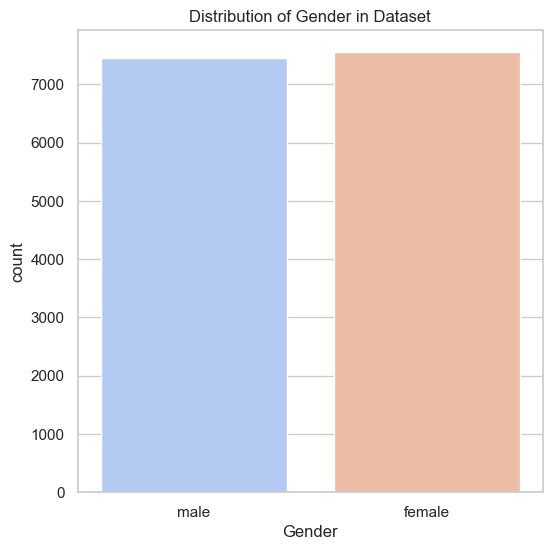

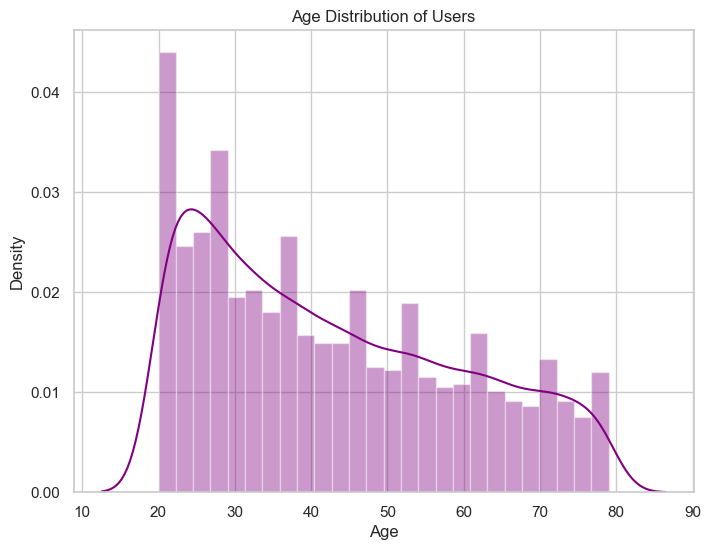

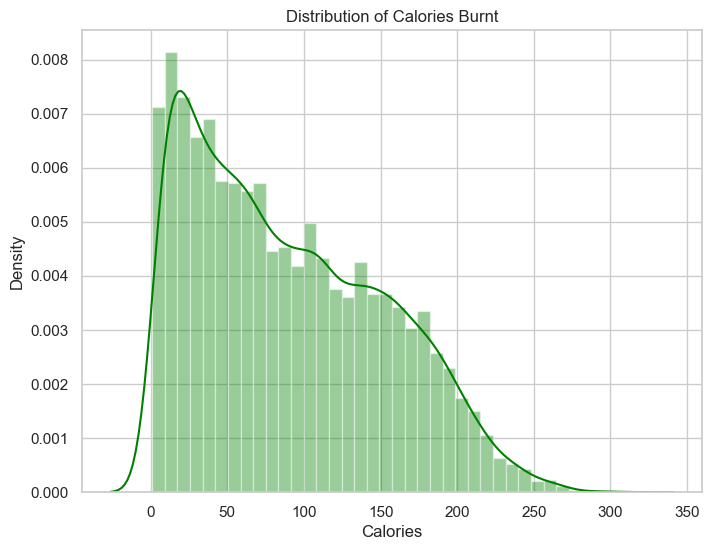

In [12]:
# PLOT 1: Gender Distribution
plt.figure(figsize=(6, 6))
sns.countplot(x='Gender', data=calories_data, palette='coolwarm')
plt.title('Distribution of Gender in Dataset')
plt.show()

# PLOT 2: Distribution of Age
# Shows if our dataset is mostly young people or mixed.
plt.figure(figsize=(8, 6))
sns.distplot(calories_data['Age'], color='purple')
plt.title('Age Distribution of Users')
plt.show()

# PLOT 3: Distribution of Target Variable (Calories)
plt.figure(figsize=(8, 6))
sns.distplot(calories_data['Calories'], color='green')
plt.title('Distribution of Calories Burnt')
plt.show()

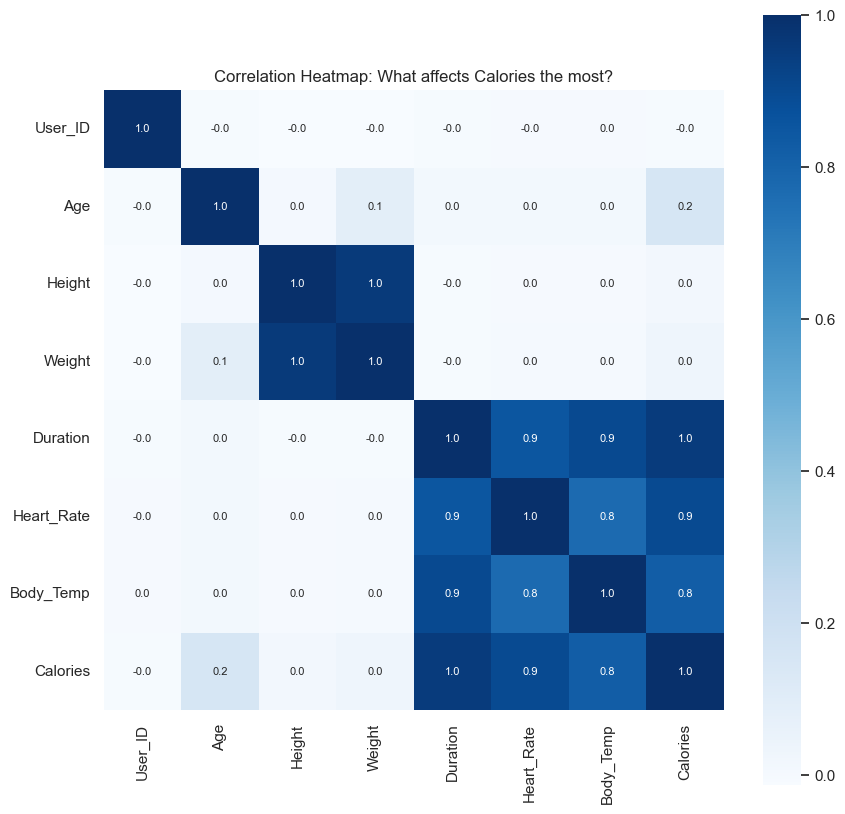

In [16]:

numeric_df = calories_data.select_dtypes(include=[np.number])

correlation = numeric_df.corr()

plt.figure(figsize=(10,10))
# Constructing a heatmap to understand the correlation
sns.heatmap(correlation, cbar=True, square=True, fmt='.1f', annot=True, annot_kws={'size':8}, cmap='Blues')
plt.title("Correlation Heatmap: What affects Calories the most?")
plt.show()


In [22]:
# Encode the 'Gender' column
# The model cannot understand "Male/Female", so we convert to 0/1.
le = LabelEncoder()
calories_data['Gender'] = le.fit_transform(calories_data['Gender'])

print(f"Classes found: {le.classes_}") 

Classes found: [0 1]


In [24]:
# Features (X) vs Target (Y)
X = calories_data.drop(columns=['User_ID', 'Calories'], axis=1)
Y = calories_data['Calories']

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=2)

print(f"Training Features Shape: {X_train.shape}")
print(f"Training Target Shape: {Y_train.shape}")

Training Features Shape: (12000, 7)
Training Target Shape: (12000,)


In [28]:
# XGBoost is a Gradient Boosting algorithm, highly effective for tabular regression.
model = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=2)

model.fit(X_train, Y_train)

print("Model trained.")

Model trained.


Mean Absolute Error (MAE): 1.51
R-Squared Score: 0.9988


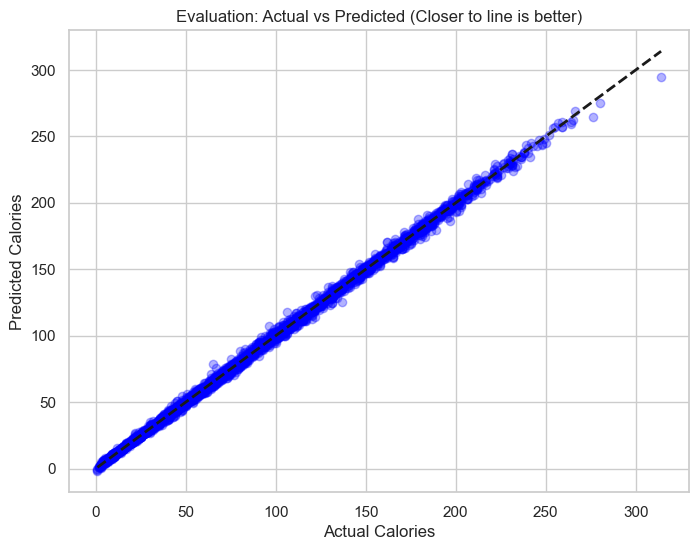

In [30]:
# Prediction on Test Data
test_data_prediction = model.predict(X_test)

# Metrics
mae = metrics.mean_absolute_error(Y_test, test_data_prediction)
r2 = metrics.r2_score(Y_test, test_data_prediction)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"R-Squared Score: {r2:.4f}")

# Visual check: Plot Actual vs Predicted
plt.figure(figsize=(8,6))
plt.scatter(Y_test, test_data_prediction, alpha=0.3, color='blue')
plt.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()], 'k--', lw=2) # Diagonal line
plt.xlabel("Actual Calories")
plt.ylabel("Predicted Calories")
plt.title("Evaluation: Actual vs Predicted (Closer to line is better)")
plt.show()

In [32]:
filename = 'calories_model.pkl'
pickle.dump(model, open(filename, 'wb'))

print("Model saved")

Model saved


In [34]:

custom_gender = 'male' 
custom_age = 25
custom_height = 175.0
custom_weight = 75.0
custom_duration = 40.0
custom_heart_rate = 145.0
custom_body_temp = 39.5

gender_numeric = 0 if custom_gender.lower() == 'female' else 1


input_data = (gender_numeric, custom_age, custom_height, custom_weight, custom_duration, custom_heart_rate, custom_body_temp)

input_data_as_numpy_array = np.asarray(input_data)
input_data_reshaped = input_data_as_numpy_array.reshape(1, -1)

# 4. Make Prediction
prediction = model.predict(input_data_reshaped)

print(f"\nUser Input Summary:")
print(f"Gender: {custom_gender}, Age: {custom_age}, Duration: {custom_duration} min")
print(f"Heart Rate: {custom_heart_rate} bpm")
print(f"-----------------------------------")
print(f" Estimated Calories Burnt: {prediction[0]:.2f} kcal")



User Input Summary:
Gender: male, Age: 25, Duration: 40.0 min
Heart Rate: 145.0 bpm
-----------------------------------
 Estimated Calories Burnt: 250.45 kcal
-----------------------------------
